In [9]:
%pip install pandas numpy matplotlib seaborn scipy statsmodels openpyxl

   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -------------- ------------------------- 3.7/9.8 MB 17.6 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.8 MB 11.2 MB/s eta 0:00:01
   ----------------------- ---------------- 5.8/9.8 MB 9.6 MB/s eta 0:00:01
   --------------------------- ------------ 6.8/9.8 MB 7.9 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.8 MB 7.5 MB/s eta 0:00:01
   --------------------------------- ------ 8.1/9.8 MB 6.4 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.8 MB 5.9 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.8 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.8 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 4.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.4 MB ? eta -:--:--
   -- ------------------------------------- 0.8/12.4 MB 4.2 MB/s eta 0:00:03
   ----- -------------

In [10]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('customer_shopping_behavior.csv')

# 2. CLEANING: Standardize names once and for all
df.columns = [col.strip().replace(' ', '_').lower() for col in df.columns]
if 'purchase_amount_(usd)' in df.columns:
    df = df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'})

# 3. FILL MISSING: Use the new lowercase names
df['review_rating'] = df.groupby('category')['review_rating'].transform(lambda x: x.fillna(x.median()))

# 4. FEATURE ENGINEERING
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels=labels)

df['spending_tier'] = pd.cut(df['purchase_amount'], bins=[0, 30, 70, 100], labels=['Budget', 'Value', 'Premium'])

# 5. SQL INTEGRATION: Save to SQLite
conn = sqlite3.connect('shopping_data.db')
df.to_sql('customer', conn, if_exists='replace', index=False)

print("Project 1 Fixed & SQL Database Created!")
df.head()

Project 1 Fixed & SQL Database Created!


,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group,spending_tier
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Middle-aged,Value
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young Adult,Value
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle-aged,Premium
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young Adult,Premium
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle-aged,Value


In [11]:
# Create a 'Spending Tier' based on the purchase amount
df['spending_tier'] = pd.cut(df['purchase_amount'], bins=[0, 30, 70, 100], labels=['Budget', 'Value', 'Premium'])

# Create Age Groups
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels=labels)

print("New Features Added: 'spending_tier' and 'age_group'")
df[['age', 'age_group', 'purchase_amount', 'spending_tier']].head()

New Features Added: 'spending_tier' and 'age_group'


,age,age_group,purchase_amount,spending_tier
0,55,Middle-aged,53,Value
1,19,Young Adult,64,Value
2,50,Middle-aged,73,Premium
3,21,Young Adult,90,Premium
4,45,Middle-aged,49,Value


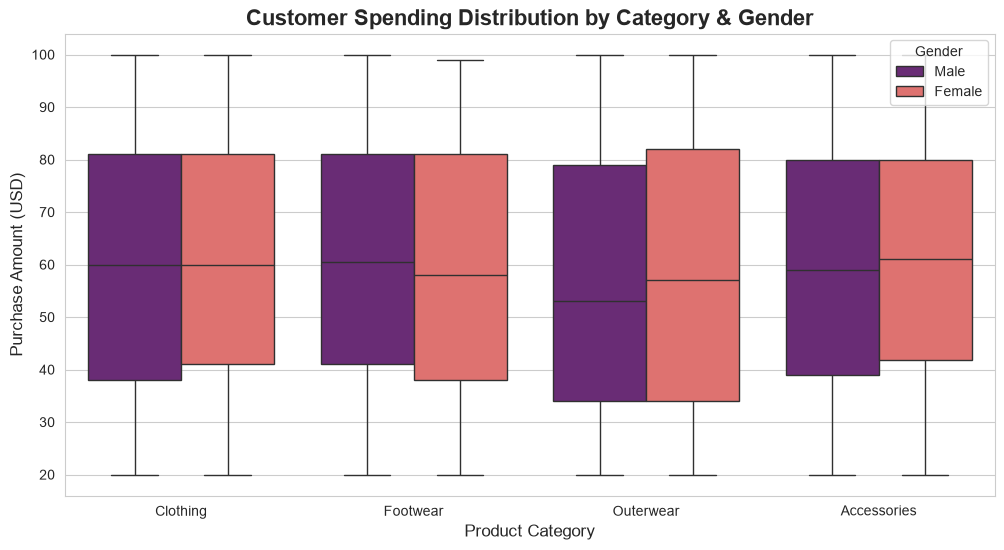

In [12]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Professional Boxplot to show spending distribution
sns.boxplot(x='category', y='purchase_amount', hue='gender', data=df, palette='magma')

plt.title('Customer Spending Distribution by Category & Gender', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Purchase Amount (USD)', fontsize=12)
plt.legend(title='Gender', loc='upper right')
plt.show()

In [13]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group,spending_tier
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Middle-aged,Value
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Young Adult,Value
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Middle-aged,Premium
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Young Adult,Premium
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Middle-aged,Value


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   customer_id             3900 non-null   int64   
 1   age                     3900 non-null   int64   
 2   gender                  3900 non-null   str     
 3   item_purchased          3900 non-null   str     
 4   category                3900 non-null   str     
 5   purchase_amount         3900 non-null   int64   
 6   location                3900 non-null   str     
 7   size                    3900 non-null   str     
 8   color                   3900 non-null   str     
 9   season                  3900 non-null   str     
 10  review_rating           3900 non-null   float64 
 11  subscription_status     3900 non-null   str     
 12  shipping_type           3900 non-null   str     
 13  discount_applied        3900 non-null   str     
 14  promo_code_used         3900 non-nu

In [15]:
# Summary statistics using .describe()
df.describe(include='all')

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,age_group,spending_tier
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7,4,3
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months,Young Adult,Value
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584,1028,1902
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750051,NaN,NaN,NaN,NaN,25.351538,NaN,NaN,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.713590,NaN,NaN,NaN,NaN,14.447125,NaN,NaN,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN,NaN,NaN


In [16]:
# Checking if missing data or null values are present in the dataset

df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount           0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
age_group                 0
spending_tier             0
dtype: int64

In [18]:
# Updated to use lowercase names
df['review_rating'] = df.groupby('category')['review_rating'].transform(lambda x: x.fillna(x.median()))

print("Missing values in 'review_rating' have been handled.")

Missing values in 'review_rating' have been handled.


In [19]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount           0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
age_group                 0
spending_tier             0
dtype: int64

In [20]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [21]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases', 'age_group',
       'spending_tier'],
      dtype='str')

In [22]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [23]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [24]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [25]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [26]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [27]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [28]:
# Dropping promo code used column

df = df.drop('promo_code_used', axis=1)

In [29]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'spending_tier',
       'purchase_frequency_days'],
      dtype='str')

In [38]:
import sqlite3

# 1. Create a local database file in your project folder
conn = sqlite3.connect('shopping_data.db')

# 2. Push your cleaned dataframe (df) into this SQL database
df.to_sql('customer', conn, if_exists='replace', index=False)

# 3. Now let's RUN one of your new SQL queries to test it
query = """
SELECT 
    gender, 
    SUM(purchase_amount) AS total_revenue,
    ROUND(100.0 * SUM(purchase_amount) / SUM(SUM(purchase_amount)) OVER(), 2) AS revenue_percentage
FROM customer
GROUP BY gender;
"""

# 4. Show the result
sql_result = pd.read_sql(query, conn)
print("SQL Query Execution Successful:")
print(sql_result)

SQL Query Execution Successful:
   gender  total_revenue  revenue_percentage
0  Female          75191               32.26
1    Male         157890               67.74
